In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Cleaning Data

In [2]:
# โหลดและทำความสะอาดข้อมูล
df = pd.read_csv("NASDAQ_100_Data_From_2010.csv", sep="\t")
df["Date"] = pd.to_datetime(df["Date"])

price_matrix = df.pivot(index="Date", columns="Name", values="Adj Close")
returns_matrix = np.log(price_matrix / price_matrix.shift(1)).iloc[1:]
clean_returns = returns_matrix.dropna(axis=1)

# Standardization (แต่ยังไม่ Transpose)
scaler = StandardScaler()
X = scaler.fit_transform(clean_returns)

stock_names = clean_returns.columns.tolist()

print("Initial Data Shape:", X.shape)
print(f"Stocks: {len(stock_names)}, Trading Days: {X.shape[0]}")

Initial Data Shape: (2942, 82)
Stocks: 82, Trading Days: 2942


#  PATH 1: Original Data (ไม่ผ่าน PCA)

In [3]:
print("\n" + "=" * 60)
print("PATH 1: Original Data (X_matrix)")
print("=" * 60)

# Transpose เพื่อให้หุ้นเป็น Samples
X_matrix = X.T  #

print(f"X_matrix shape: {X_matrix.shape}")
print(f"(หุ้น={X_matrix.shape[0]}, วัน={X_matrix.shape[1]})")

results = {
    "stock_names": stock_names,
    "X_matrix": X_matrix,
    "clean_returns": clean_returns,
    "scaler": scaler
}


PATH 1: Original Data (X_matrix)
X_matrix shape: (82, 2942)
(หุ้น=82, วัน=2942)



PATH 2: PCA Reduction (X_PCA)
X_matrix (ต้นฉบับ) shape: (82, 2942)
X_PCA (หลังผ่าน PCA) shape: (82, 69)
จำนวน Components: 69
Cumulative Variance Explained: 0.9543
Dimensionality reduction: 2942 → 69


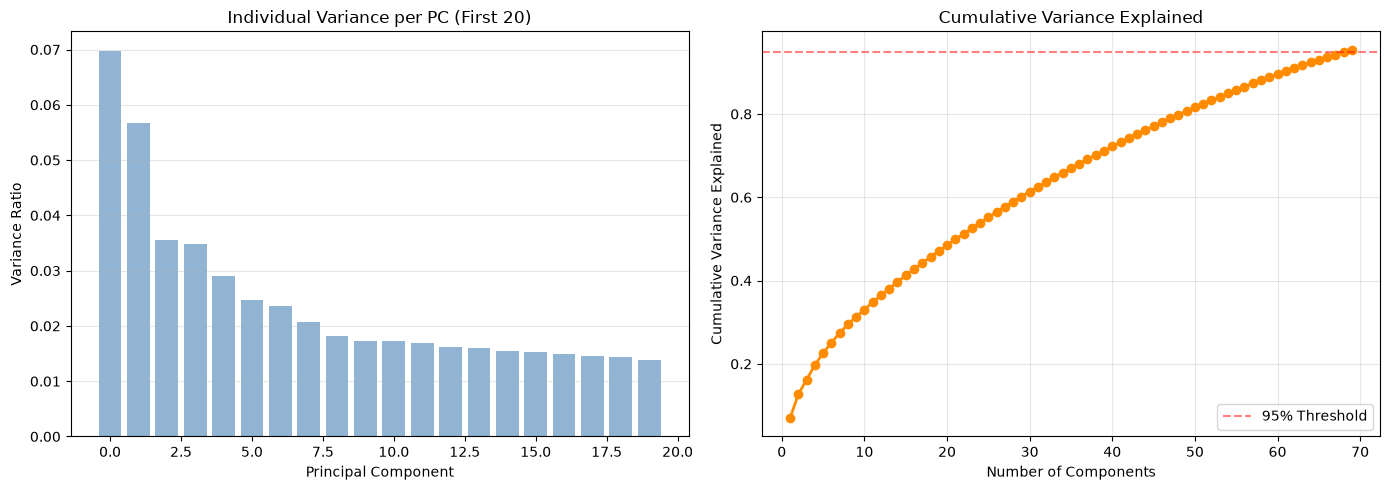

In [4]:
print("\n" + "=" * 60)
print("PATH 2: PCA Reduction (X_PCA)")
print("=" * 60)

#  FIX: ทำ PCA บน X_matrix (82 หุ้น, 2942 วัน)
pca = PCA(n_components=0.95, random_state=42)
X_PCA = pca.fit_transform(X_matrix)

n_components = X_PCA.shape[1]
cum_var = np.cumsum(pca.explained_variance_ratio_)

print(f"X_matrix (ต้นฉบับ) shape: {X_matrix.shape}")
print(f"X_PCA (หลังผ่าน PCA) shape: {X_PCA.shape}")
print(f"จำนวน Components: {n_components}")
print(f"Cumulative Variance Explained: {cum_var[-1]:.4f}")
print(f"Dimensionality reduction: {X_matrix.shape[1]} → {X_PCA.shape[1]}")

results["pca_model"] = pca
results["X_PCA"] = X_PCA

# Plot: PCA Scree Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot - Individual variance
ax1.bar(range(len(pca.explained_variance_ratio_[:20])),
        pca.explained_variance_ratio_[:20],
        alpha=0.6, color='steelblue')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Ratio')
ax1.set_title('Individual Variance per PC (First 20)')
ax1.grid(axis='y', alpha=0.3)

# Line plot - Cumulative variance
ax2.plot(range(1, len(cum_var) + 1), cum_var, 'o-', color='darkorange', linewidth=2)
ax2.axhline(y=0.95, color='red', linestyle='--', alpha=0.5, label='95% Threshold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance Explained')
ax2.set_title('Cumulative Variance Explained')
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# ทำt-SNE บน PATH 1 (X_matrix)

In [5]:
print("\n" + "=" * 60)
print("STEP 4.1: t-SNE บน X_matrix (Original Data)")
print("=" * 60)

tsne_1 = TSNE(n_components=2, perplexity=5, random_state=42)
tsne_X_matrix = tsne_1.fit_transform(X_matrix)

tsne_X_matrix_df = pd.DataFrame(
    tsne_X_matrix,
    columns=["Dim1", "Dim2"],
    index=stock_names
)

results["tsne_X_matrix"] = tsne_X_matrix_df

print("t-SNE (X_matrix) - ตัวอย่าง:")
print(tsne_X_matrix_df.head())
print(f"Shape: {tsne_X_matrix_df.shape}")


STEP 4.1: t-SNE บน X_matrix (Original Data)
t-SNE (X_matrix) - ตัวอย่าง:
           Dim1       Dim2
AAPL   9.595278  -1.796184
ADBE   6.439882   1.135665
ADI   23.381592  13.423829
ADP  -10.243598 -16.394571
ADSK   5.039843   2.567079
Shape: (82, 2)


# ทำt-SNE บน PATH 2 (X_PCA)

In [6]:
print("\n" + "=" * 60)
print("STEP 4.2: t-SNE บน X_PCA (After PCA)")
print("=" * 60)

tsne_2 = TSNE(n_components=2, perplexity=5, random_state=42)
tsne_X_PCA = tsne_2.fit_transform(X_PCA)

tsne_X_PCA_df = pd.DataFrame(
    tsne_X_PCA,
    columns=["Dim1", "Dim2"],
    index=stock_names
)

results["tsne_X_PCA"] = tsne_X_PCA_df

print("t-SNE (X_PCA) - ตัวอย่าง:")
print(tsne_X_PCA_df.head())
print(f"Shape: {tsne_X_PCA_df.shape}")


STEP 4.2: t-SNE บน X_PCA (After PCA)
t-SNE (X_PCA) - ตัวอย่าง:
           Dim1       Dim2
AAPL  10.574768  -8.409899
ADBE   7.704086 -10.026695
ADI   13.201422   3.889856
ADP   -8.504466   0.228300
ADSK   6.380335 -10.397386
Shape: (82, 2)


# VISUALIZATION: เปรียบเทียบ t-SNE ทั้ง 2 Path

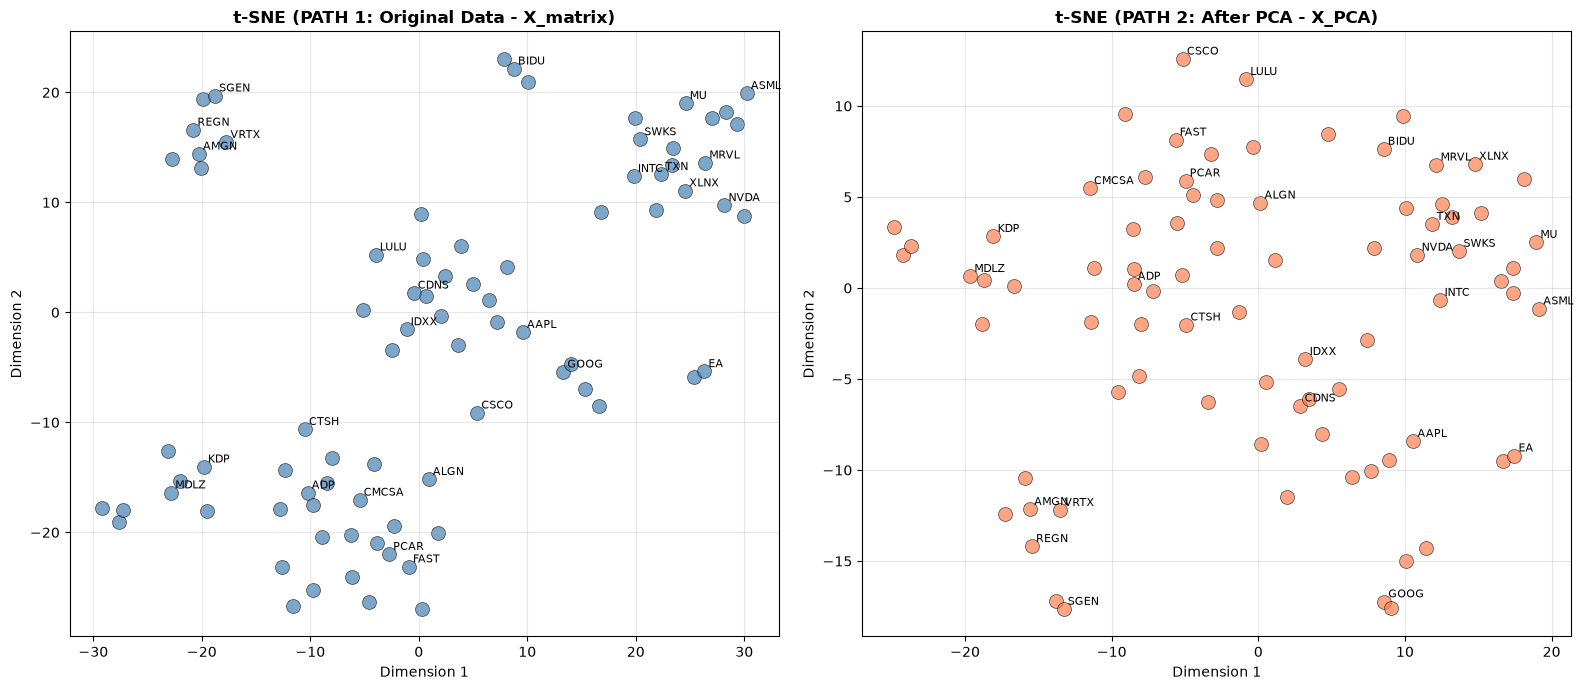

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Path 1: Original
axes[0].scatter(tsne_X_matrix_df["Dim1"], tsne_X_matrix_df["Dim2"],
                s=100, alpha=0.7, c='steelblue', edgecolors='black', linewidth=0.5)
for ticker in stock_names[::3]:
    idx = stock_names.index(ticker)
    axes[0].annotate(ticker,
                     (tsne_X_matrix_df.iloc[idx, 0], tsne_X_matrix_df.iloc[idx, 1]),
                     fontsize=8, xytext=(3, 3), textcoords="offset points")

axes[0].set_title("t-SNE (PATH 1: Original Data - X_matrix)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Dimension 1")
axes[0].set_ylabel("Dimension 2")
axes[0].grid(alpha=0.3)

# Path 2: PCA
axes[1].scatter(tsne_X_PCA_df["Dim1"], tsne_X_PCA_df["Dim2"],
                s=100, alpha=0.7, c='coral', edgecolors='black', linewidth=0.5)
for ticker in stock_names[::3]:
    idx = stock_names.index(ticker)
    axes[1].annotate(ticker,
                     (tsne_X_PCA_df.iloc[idx, 0], tsne_X_PCA_df.iloc[idx, 1]),
                     fontsize=8, xytext=(3, 3), textcoords="offset points")

axes[1].set_title("t-SNE (PATH 2: After PCA - X_PCA)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Dimension 1")
axes[1].set_ylabel("Dimension 2")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


--- K-Means: X_matrix ---
   Stock  Cluster
0   AAPL        0
1   ADBE        0
2    ADI        1
3    ADP        2
4   ADSK        0
..   ...      ...
77  VRSN        0
78  VRTX        0
79   WBA        2
80   XEL        2
81  XLNX        1

[82 rows x 2 columns]

--- K-Means: X_PCA ---
   Stock  Cluster
0   AAPL        1
1   ADBE        1
2    ADI        0
3    ADP        1
4   ADSK        1
..   ...      ...
77  VRSN        1
78  VRTX        1
79   WBA        2
80   XEL        2
81  XLNX        0

[82 rows x 2 columns]

CLUSTER SIZE

Original Data:
Cluster
0    33
1    19
2    30
Name: count, dtype: int64

PCA Data:
Cluster
0    19
1    54
2     9
Name: count, dtype: int64


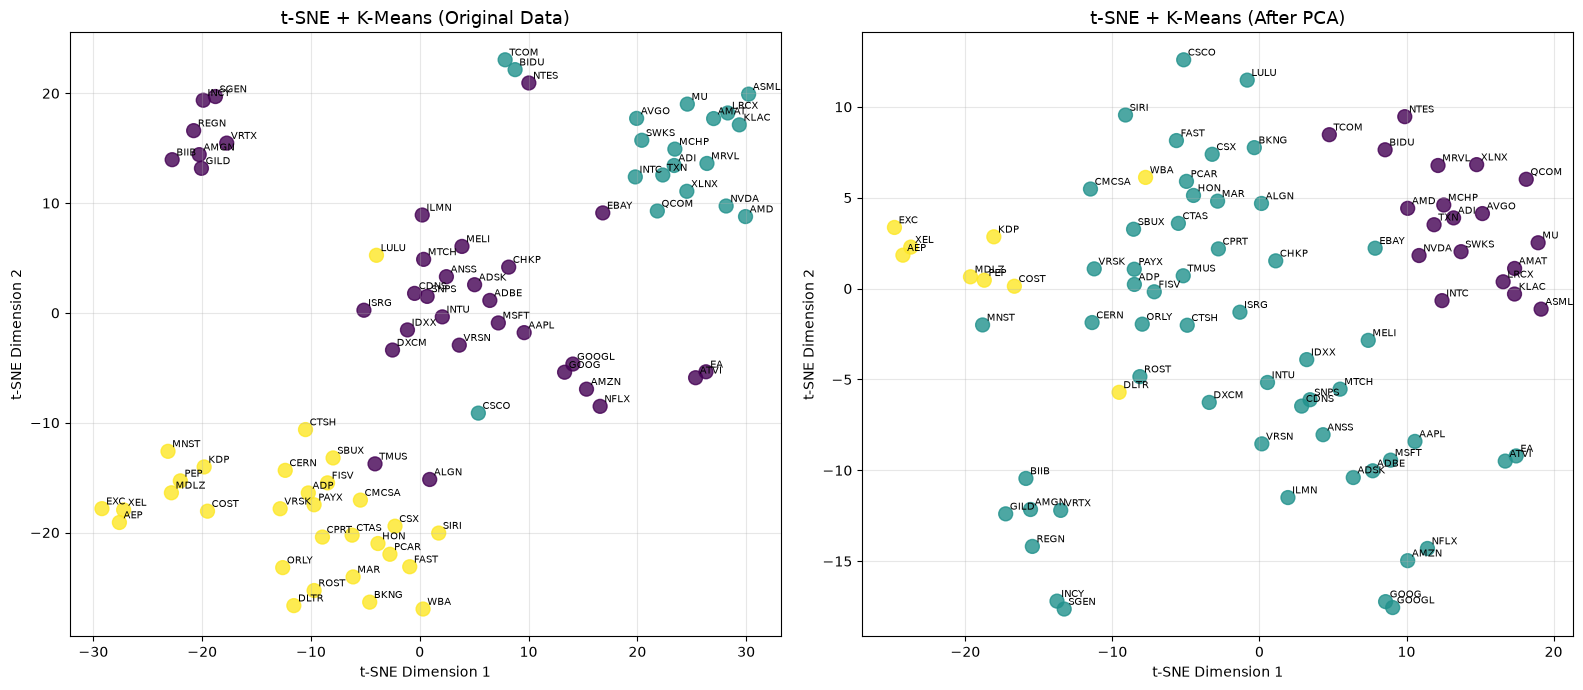


K-MEANS COMPARISON
   Stock  Cluster_Original  Cluster_PCA
0   AAPL                 0            1
1   ADBE                 0            1
2    ADI                 1            0
3    ADP                 2            1
4   ADSK                 0            1
..   ...               ...          ...
77  VRSN                 0            1
78  VRTX                 0            1
79   WBA                 2            2
80   XEL                 2            2
81  XLNX                 1            0

[82 rows x 3 columns]


In [8]:

from sklearn.cluster import KMeans
K = 3


# ------------------------------------------------
# K-Means PATH 1
# X_matrix → K-Means
# ------------------------------------------------

print("\n--- K-Means: X_matrix ---")

kmeans_matrix = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

labels_matrix = kmeans_matrix.fit_predict(X_matrix)

cluster_matrix_df = pd.DataFrame({
    "Stock": stock_names,
    "Cluster": labels_matrix
})

print(cluster_matrix_df)


# ------------------------------------------------
# K-Means PATH 2
# X_PCA → K-Means
# ------------------------------------------------

print("\n--- K-Means: X_PCA ---")

kmeans_pca = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

labels_pca = kmeans_pca.fit_predict(X_PCA)

cluster_pca_df = pd.DataFrame({
    "Stock": stock_names,
    "Cluster": labels_pca
})

print(cluster_pca_df)


# ================================================================
# ดูจำนวนหุ้นในแต่ละ Cluster
# ================================================================

print("\n" + "=" * 60)
print("CLUSTER SIZE")
print("=" * 60)

print("\nOriginal Data:")
print(
    cluster_matrix_df["Cluster"]
    .value_counts()
    .sort_index()
)

print("\nPCA Data:")
print(
    cluster_pca_df["Cluster"]
    .value_counts()
    .sort_index()
)


# ================================================================
# รวม Cluster Labels เข้ากับ t-SNE
# ================================================================

tsne_X_matrix_df["Cluster"] = labels_matrix
tsne_X_PCA_df["Cluster"] = labels_pca


# ================================================================
# VISUALIZATION
# t-SNE + K-Means
# ================================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 7)
)


# ------------------------------------------------
# GRAPH 1
# X_matrix → t-SNE + K-Means
# ------------------------------------------------

axes[0].scatter(
    tsne_X_matrix_df["Dim1"],
    tsne_X_matrix_df["Dim2"],
    c=tsne_X_matrix_df["Cluster"],
    s=100,
    alpha=0.8
)

for ticker in stock_names:
    axes[0].annotate(
        ticker,
        (
            tsne_X_matrix_df.loc[ticker, "Dim1"],
            tsne_X_matrix_df.loc[ticker, "Dim2"]
        ),
        fontsize=7,
        xytext=(3, 3),
        textcoords="offset points"
    )

axes[0].set_title(
    "t-SNE + K-Means (Original Data)",
    fontsize=13
)

axes[0].set_xlabel("t-SNE Dimension 1")
axes[0].set_ylabel("t-SNE Dimension 2")
axes[0].grid(alpha=0.3)


# ------------------------------------------------
# GRAPH 2
# X_PCA → t-SNE + K-Means
# ------------------------------------------------

axes[1].scatter(
    tsne_X_PCA_df["Dim1"],
    tsne_X_PCA_df["Dim2"],
    c=tsne_X_PCA_df["Cluster"],
    s=100,
    alpha=0.8
)

for ticker in stock_names:
    axes[1].annotate(
        ticker,
        (
            tsne_X_PCA_df.loc[ticker, "Dim1"],
            tsne_X_PCA_df.loc[ticker, "Dim2"]
        ),
        fontsize=7,
        xytext=(3, 3),
        textcoords="offset points"
    )

axes[1].set_title(
    "t-SNE + K-Means (After PCA)",
    fontsize=13
)

axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ================================================================
# COMPARISON TABLE
# ================================================================

comparison_df = pd.DataFrame({
    "Stock": stock_names,
    "Cluster_Original": labels_matrix,
    "Cluster_PCA": labels_pca
})

print("\n" + "=" * 60)
print("K-MEANS COMPARISON")
print("=" * 60)

print(comparison_df)
